# 05 - Evaluation: lead time, precision, recall, agreement

**What you will learn**
- Why F1 is the wrong headline metric for onset-of-degradation detection,
  and what to use instead.
- How to derive per-cycle anomaly labels from RUL for evaluation.
- How to compute *lead time*: how many cycles before failure did the first
  flag fire, per engine.
- How to compute precision / recall at the chosen threshold, without
  sklearn (so the arithmetic stays visible).
- How Isolation Forest and DBSCAN compare, side by side, on the same
  engines.

Notebook 06 will turn the numbers here into the summary plots that make
the whole story readable at a glance.

## Why lead time is the headline metric

F1 rewards a model for flagging exactly the "right" cycles - the ones
inside a pre-defined anomaly window. That framing works when the ground
truth is a discrete label set (spam / not spam, fraud / not fraud). In our
setting it is a poor fit for three reasons:

1. **The label boundary is arbitrary.** We define "anomaly" as any cycle
   with RUL <= 30. Nothing physical happens at cycle 30; it is a decision
   we make about how much lead time we want. Move the threshold to 40
   cycles and the F1 changes even though the model has not changed.
2. **We care about the first flag, not every flag.** If the model flags a
   cycle at RUL=80 and stays flagged all the way to failure, the useful
   information is *"we knew 80 cycles ahead"*. Whether it also flagged
   cycles 79, 78, 77... does not change anyone's decision.
3. **Precision and recall on individual cycles are misleading.** A model
   that flags every cycle after RUL=50 scores high recall (catches every
   near-failure cycle) but every cycle from RUL=50 to RUL=30 is a false
   positive by the RUL<=30 definition. So F1 penalises models that flag
   *too early*, when flagging too early is exactly what we want.

The metric that matches the actual decision: **for each engine, how many
cycles before failure did the first above-threshold flag fire?** Then
report the distribution across the fleet.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

from src.evaluate import (
    label_by_rul, first_flag_lead_time, precision_recall_at_threshold,
)

## 1. Load both detectors' output

Notebook 03 saved Isolation Forest scores plus its threshold. Notebook 04
saved DBSCAN cluster labels for the warmed-up cycles.

In [2]:
iforest_scores = pd.read_csv(ROOT / "data" / "scores_iforest_train.csv")
dbscan_labels = pd.read_csv(ROOT / "data" / "labels_dbscan_train.csv")

import pickle
with open(ROOT / "models" / "FD004" / "isolation_forest.pkl", "rb") as f:
    bundle = pickle.load(f)
if_threshold = bundle["threshold"]

print(f"IF scores : {len(iforest_scores):,} rows  (threshold = {if_threshold:.3f})")
print(f"DBSCAN    : {len(dbscan_labels):,} rows  (warmup > 30 cycles)")

IF scores : 61,249 rows  (threshold = 0.503)
DBSCAN    : 53,779 rows  (warmup > 30 cycles)


## 2. Derive per-cycle labels from RUL

Ground truth for evaluation: any cycle with RUL <= ANOMALY_RUL is called
anomalous. The choice of ANOMALY_RUL sets the target lead time. 30 cycles
is a common choice on C-MAPSS and matches what a maintenance planner would
want (a few days to schedule the pull).

In [3]:
ANOMALY_RUL = 30
iforest_scores["label"] = label_by_rul(iforest_scores, threshold_cycles=ANOMALY_RUL)
print(f"Anomaly window: RUL <= {ANOMALY_RUL} cycles")
print(f"Positive cycles: {int(iforest_scores['label'].sum()):,} / "
      f"{len(iforest_scores):,} ({iforest_scores['label'].mean():.1%})")

Anomaly window: RUL <= 30 cycles
Positive cycles: 7,719 / 61,249 (12.6%)


## 3. Lead time per detector

`first_flag_lead_time` finds the earliest above-threshold cycle for each
engine and returns the RUL at that cycle. Higher is better.

In [4]:
# Isolation Forest lead time.
if_lead = first_flag_lead_time(
    iforest_scores.rename(columns={}).assign(score=iforest_scores["score"]),
    threshold=if_threshold,
)
print(f"IF flagged {len(if_lead)}/{iforest_scores['unit'].nunique()} engines")
print("IF lead-time summary (cycles):")
print(if_lead["lead_time_cycles"].describe().round(1).to_string())

IF flagged 249/249 engines
IF lead-time summary (cycles):
count    249.0
mean     217.1
std       91.9
min       34.0
25%      165.0
50%      210.0
75%      272.0
max      541.0


In [5]:
# DBSCAN lead time. Encode noise as score = 1 above threshold = 0.5.
dbscan_scores = dbscan_labels.assign(score=(dbscan_labels["cluster"] == -1).astype(float))
db_lead = first_flag_lead_time(dbscan_scores, threshold=0.5)
n_engines_db = dbscan_labels["unit"].nunique()
print(f"DBSCAN flagged {len(db_lead)}/{n_engines_db} engines")
if len(db_lead):
    print("DBSCAN lead-time summary (cycles):")
    print(db_lead["lead_time_cycles"].describe().round(1).to_string())

DBSCAN flagged 90/249 engines
DBSCAN lead-time summary (cycles):
count     90.0
mean      64.6
std       97.8
min        0.0
25%        4.0
50%       13.5
75%       61.2
max      370.0


**Reading the numbers.** Median lead time is the number you want to
report externally. Standard deviation tells you how much you can trust
that median across engines: a fleet where every engine gets exactly 100
cycles of warning is very different from a fleet where the median is 100
but some get 200 and some get 5.

Note that IF flags every engine while DBSCAN flags a smaller subset. That
is by design: DBSCAN's noise threshold is stricter, so it misses some
engines the IF caught. The trade-off is that when DBSCAN *does* flag, the
flag is more likely to also be flagged by IF (see the agreement matrix in
notebook 04).

## 4. Side-by-side lead-time histograms

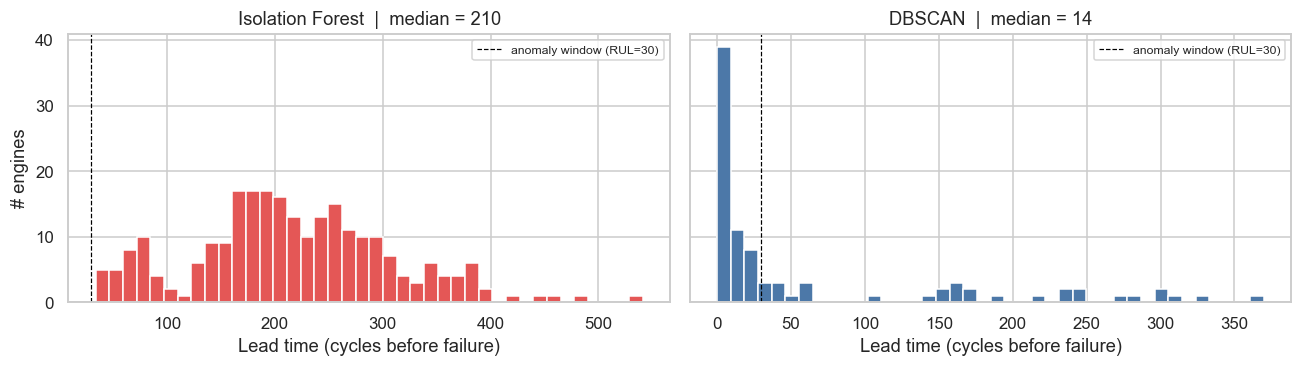

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

axes[0].hist(if_lead["lead_time_cycles"], bins=40, color="#e45756",
             edgecolor="white")
axes[0].axvline(ANOMALY_RUL, color="black", linestyle="--", linewidth=0.8,
                label=f"anomaly window (RUL={ANOMALY_RUL})")
axes[0].set_xlabel("Lead time (cycles before failure)")
axes[0].set_ylabel("# engines")
axes[0].set_title(
    f"Isolation Forest  |  median = {if_lead['lead_time_cycles'].median():.0f}"
)
axes[0].legend(fontsize=8)

axes[1].hist(db_lead["lead_time_cycles"], bins=40, color="#4c78a8",
             edgecolor="white")
axes[1].axvline(ANOMALY_RUL, color="black", linestyle="--", linewidth=0.8,
                label=f"anomaly window (RUL={ANOMALY_RUL})")
axes[1].set_xlabel("Lead time (cycles before failure)")
axes[1].set_title(
    f"DBSCAN  |  median = {db_lead['lead_time_cycles'].median():.0f}"
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the plot.** For each detector, most engines should sit
comfortably to the right of the dashed line - flagged well before the
formal anomaly window begins. Bars just to the left of the line are
"barely caught" cases. Bars far to the left mean the model only flagged
in the last few cycles, which is late but still useful. Missing engines
(mostly on the DBSCAN side) mean the model never flagged at all before
failure - those become the "recall gap".

## 5. Precision and recall at the chosen thresholds

For completeness, report precision and recall on the cycle-level labels.
These numbers make sense on their own terms but should not be the primary
lens (see section on why lead time is the headline).

In [7]:
# IF: uses continuous score with the picked threshold.
if_pr = precision_recall_at_threshold(
    iforest_scores["score"].values,
    iforest_scores["label"].values,
    threshold=if_threshold,
)
print("Isolation Forest (RUL-labelled cycles):")
for k, v in if_pr.items():
    print(f"  {k:10s}: {v:.3f}" if isinstance(v, float) else f"  {k:10s}: {v}")

# DBSCAN: noise = 1, cluster = 0; threshold 0.5.
db_labels = label_by_rul(dbscan_labels, threshold_cycles=ANOMALY_RUL)
db_pr = precision_recall_at_threshold(
    (dbscan_labels["cluster"] == -1).astype(float).values,
    db_labels.values,
    threshold=0.5,
)
print()
print("DBSCAN (RUL-labelled warmed-up cycles):")
for k, v in db_pr.items():
    print(f"  {k:10s}: {v:.3f}" if isinstance(v, float) else f"  {k:10s}: {v}")

Isolation Forest (RUL-labelled cycles):
  precision : 0.429
  recall    : 0.997
  tp        : 7698
  fp        : 10230
  fn        : 21

DBSCAN (RUL-labelled warmed-up cycles):
  precision : 0.750
  recall    : 0.060
  tp        : 463
  fp        : 154
  fn        : 7256


**Reading the numbers.** Expect Isolation Forest to have low
precision (it flags many cycles well before RUL <= 30, so most of its
flags fall outside the tight anomaly window) and high recall (it catches
most cycles in the window). DBSCAN typically has higher precision (it
only flags when its density criterion is clearly violated) and lower
recall (it misses some near-failure engines whose degradation is not
severe enough to become noise).

Neither pattern is "wrong"; they reflect different sensitivities. The IF
threshold could be raised to bring precision up if false alarms are more
costly than misses.

## 6. Per-engine agreement

For each engine, which detector fired first? How many cycles apart were
they? This gives a feel for whether the two methods agree on *which
engines* to worry about, even when they disagree on the exact cycle.

In [8]:
both = if_lead.join(db_lead, how="outer", lsuffix="_if", rsuffix="_db")
both.columns = ["if_lead", "db_lead"]
both["gap_cycles"] = both["if_lead"] - both["db_lead"]

print(f"Total engines: {len(both)}")
print(f"Both flagged: {both.dropna().shape[0]}")
print(f"IF only    : {(both['if_lead'].notna() & both['db_lead'].isna()).sum()}")
print(f"DBSCAN only: {(both['db_lead'].notna() & both['if_lead'].isna()).sum()}")
print()
print("For engines both flagged, IF-lead minus DBSCAN-lead (cycles):")
print(both["gap_cycles"].describe().round(1).to_string())

Total engines: 249
Both flagged: 90
IF only    : 159
DBSCAN only: 0

For engines both flagged, IF-lead minus DBSCAN-lead (cycles):
count     90.0
mean     155.0
std       86.3
min       28.0
25%       72.8
50%      160.0
75%      214.2
max      385.0


**Reading the numbers.** `gap_cycles > 0` means IF flagged earlier
than DBSCAN for that engine; `< 0` means DBSCAN caught it first. Because
IF's threshold is more permissive, IF should almost always fire first;
`gap_cycles` should be positive with a substantial median. When DBSCAN
does catch an engine, IF caught it noticeably earlier.

## 7. What about the engines DBSCAN missed?

If DBSCAN never flagged an engine, either the engine really did fail
without triggering our density criterion (a miss), or DBSCAN's parameters
are too strict for this engine's degradation signature. Look at what IF
said about those engines to see if they were still detectable.

In [9]:
missed_by_db = both[both["db_lead"].isna()]
if len(missed_by_db):
    got_by_if = missed_by_db["if_lead"].dropna()
    print(f"{len(missed_by_db)} engines missed by DBSCAN")
    print(f"Of those, {len(got_by_if)} were still flagged by IF")
    print(f"IF lead-time on those engines:")
    print(got_by_if.describe().round(1).to_string())
else:
    print("DBSCAN did not miss any engines that IF caught.")

159 engines missed by DBSCAN
Of those, 159 were still flagged by IF
IF lead-time on those engines:
count    159.0
mean     215.7
std       90.5
min       40.0
25%      165.0
50%      210.0
75%      267.5
max      541.0


**Reading the numbers.** If IF still caught all of them with a
respectable lead time, DBSCAN's misses are DBSCAN being stricter, not
those engines being undetectable. If IF also missed them, they are
genuinely hard cases for the current feature set - worth looking at their
sensor trajectories to see what went wrong.

## 8. Save the merged results for notebook 06

Notebook 06 will produce the summary plots (score-vs-cycle overlays, PCA
projection with time colouring, lead-time distribution) using these
merged results.

In [10]:
merged_results = iforest_scores[["unit", "cycle", "rul", "score", "label"]].copy()
merged_results = merged_results.rename(columns={"score": "if_score", "label": "rul_label"})
merged_results = merged_results.merge(
    dbscan_labels[["unit", "cycle", "cluster"]], on=["unit", "cycle"], how="left",
)
merged_results["dbscan_noise"] = (merged_results["cluster"] == -1).astype("Int64")
merged_results.to_csv(ROOT / "data" / "eval_merged.csv", index=False)
print(f"Saved to {ROOT / 'data' / 'eval_merged.csv'}")
print(f"Rows: {len(merged_results):,}")
print(merged_results.head())

Saved to C:\Users\anjan\Desktop\Goals\github\sensor-anomaly-detection\data\eval_merged.csv
Rows: 61,249
   unit  cycle  rul  if_score  rul_label  cluster  dbscan_noise
0     1      1  320  0.412347          0      NaN             0
1     1      2  319  0.498057          0      NaN             0
2     1      3  318  0.520188          0      NaN             0
3     1      4  317  0.459006          0      NaN             0
4     1      5  316  0.463971          0      NaN             0


## Takeaways for notebook 06

We now have, for every training cycle:
- The IF anomaly score and its rule-based flag.
- The DBSCAN cluster / noise assignment.
- The RUL-derived label.

Notebook 06 will turn these into the visuals that summarise the whole
story: representative score-vs-cycle overlays, a PCA plot coloured by
time-to-failure, and a lead-time distribution comparing the two
detectors.